###### Load Dependencies

In [1]:
from importlib import reload
import numpy as np
import scalers
from data import *
from classifications import *
from imputers import *
from scalers import StandardScaler, NormalScaler
import data as db
import matplotlib.pyplot as plt
reload( db )
import pandas as pd
import warnings

In [2]:
hdr = '\r\n' + '-' * 120 + '\r\n'
nwln = '\r\n'
warnings.filterwarnings( 'ignore' )

###### Load Data

In [3]:
# Load Data
schedx_filepath = r'C:\Users\terry\source\repos\mathy\stores\excel\Combined Schedules.xlsx'
index_columns = [ 'CombinedSchedulesId', ]
nominal_columns = [ 'MainAccount', 'TreasurySymbol', 'AccountName',
					'LineName', 'Line', 'Subfunction', 'Classification', 'BudgetEnforcementCategory' ]
out_years = [ f'OY-{i}' for i in range( 1, 10 ) ]
numeric_columns = index_columns + [ 'PY', 'CY', 'BY' ]
data_columns = [ 'MainAccount', 'Line' ]
all_columns = nominal_columns + numeric_columns
drop_columns = [ 'LineName', 'Subfunction', 'Classification', 'BudgetEnforcementCategory' ]
max_columns = data_columns + numeric_columns

# Read Excel, set index and load columns# Reload with corrected dtypes and padding for codes
dtype_dict = \
{
	'MainAccount': str,
	'TreasurySymbol': str
}

df_excel = pd.read_excel( schedx_filepath, usecols=all_columns, sheet_name='Data'  )
df_excel.reset_index( )
df_excel.round( 2 )
# Fix formatting: pad with leading zeros and split TreasurySymbol
df_excel[ 'MainAccount' ] = df_excel[ 'MainAccount' ].str.replace( 'A-', '', regex=False )
df_excel[ 'MainAccount' ] = df_excel[ 'MainAccount' ].str.zfill( 4 )
df_excel[ 'TreasurySymbol' ] = df_excel[ 'TreasurySymbol' ].str.replace( 'A-', '', regex=False )
df_excel[ 'Line' ] = df_excel[ 'Line' ].str.replace( 'L-', '', regex=False )
df_excel[ 'Line' ] = df_excel[ 'Line' ].str.zfill( 4 )
df_excel[ 'AgencyCode' ] = df_excel[ 'TreasurySymbol' ].str[ :3 ].str.zfill( 3 )
df_excel[ 'MainAccountCode' ] = df_excel[ 'TreasurySymbol' ].str[ 3: ].str.zfill( 4 )

df_excel[ numeric_columns ] = df_excel[ numeric_columns ].round( 2 )
df_dataset = df_excel[ all_columns ].copy( )
df_nominal = df_excel[ nominal_columns ].copy( )
df_numeric = df_excel[ numeric_columns ].copy( )
df_schedx = df_excel[ max_columns ].copy( )
sns.set_style( 'darkgrid' )

In [4]:
ds = db.DataSource( df=df_schedx, target='BY' )
training_data = ds.X_train
training_values = ds.y_train
testing_data = ds.X_test
testing_values = ds.y_test

In [5]:
# Standardized data
scaler = StandardScaler( )
std_data = scaler.train_transform( ds.data )
std_training = scaler.train_transform( training_data )
std_testing = scaler.train_transform( testing_data )

# Normalized data
normal = NormalScaler( )
nrm_data = normal.train_transform( ds.data )
nrm_training = normal.train_transform( training_data )
nrm_testing = normal.train_transform( testing_data )

In [11]:
pr = LogisticRegression( )
pr.train( ds.data, ds.targets )

In [12]:
prediction = pr.project( ds.data, ds.targets )
prediction

array([  16099000000,   16099000000,   16099000000, ...,   11633000000,
         11633000000, 4528039000000], shape=(2400,))

In [13]:
score = pr.score( ds.data, ds.targets )
score


,Accuracy,F1-Score,Recall,Precision
0,0.378333,0.153846,1.0,0.083333
1,0.378333,1.000000,1.0,1.000000
2,0.378333,0.000000,0.0,0.000000
3,0.378333,0.000000,0.0,0.000000
4,0.378333,0.000000,0.0,0.000000
...,...,...,...,...
421,0.378333,0.000000,0.0,0.000000
422,0.378333,0.000000,0.0,0.000000
423,0.378333,0.000000,0.0,0.000000
424,0.378333,0.000000,0.0,0.000000


In [14]:
analytics = pr.analyze( ds.data, ds.targets )
analytics


,Mean Squared Error,Root Mean Squared Error,Mean Absolute Error,Median Absolute Error
0,7.378084e+17,8.589577e+08,1.689522e+11,2.078000e+09


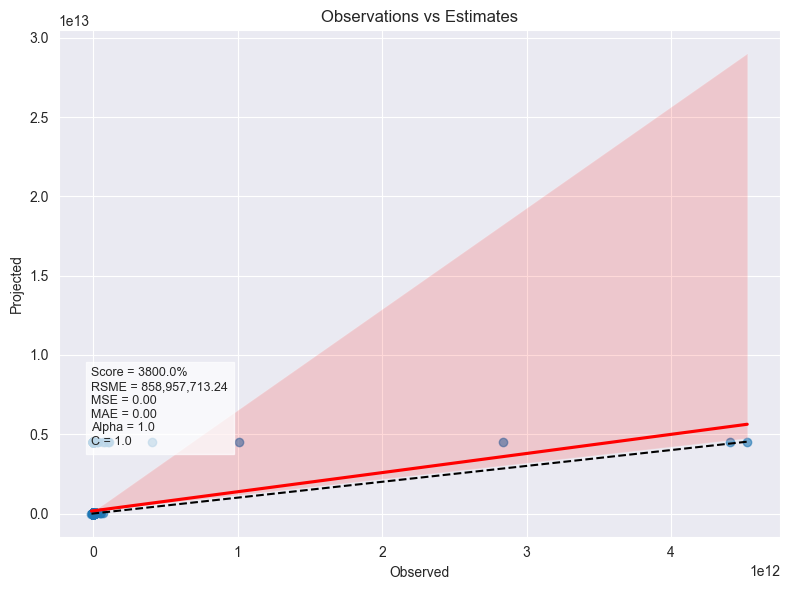

In [15]:
pr.scatter_plot(  ds.data, ds.targets )